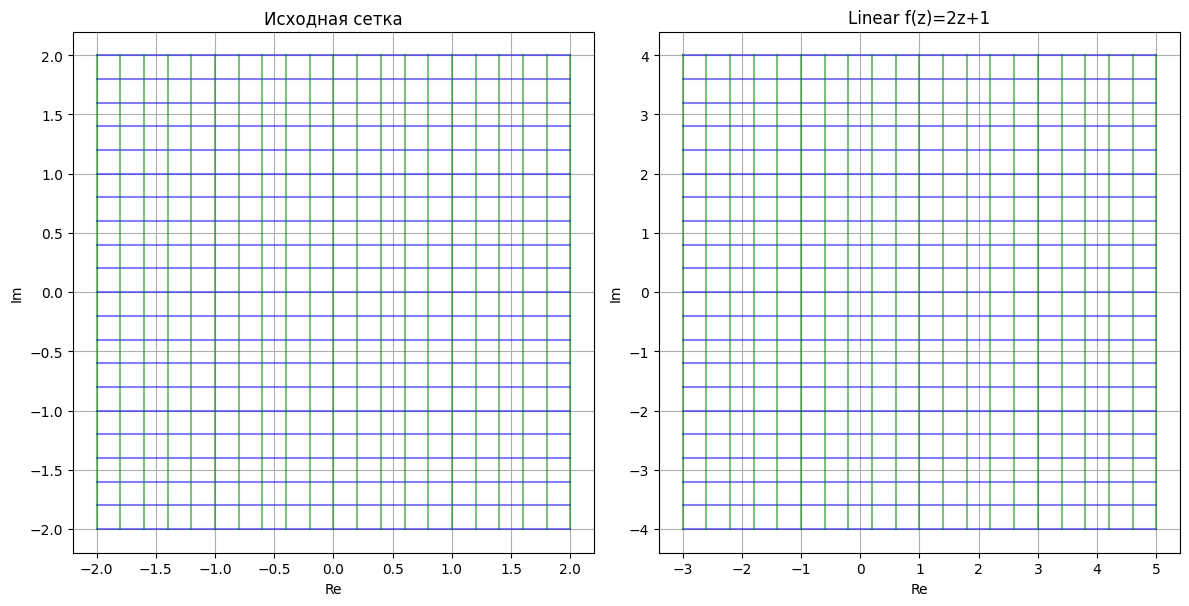

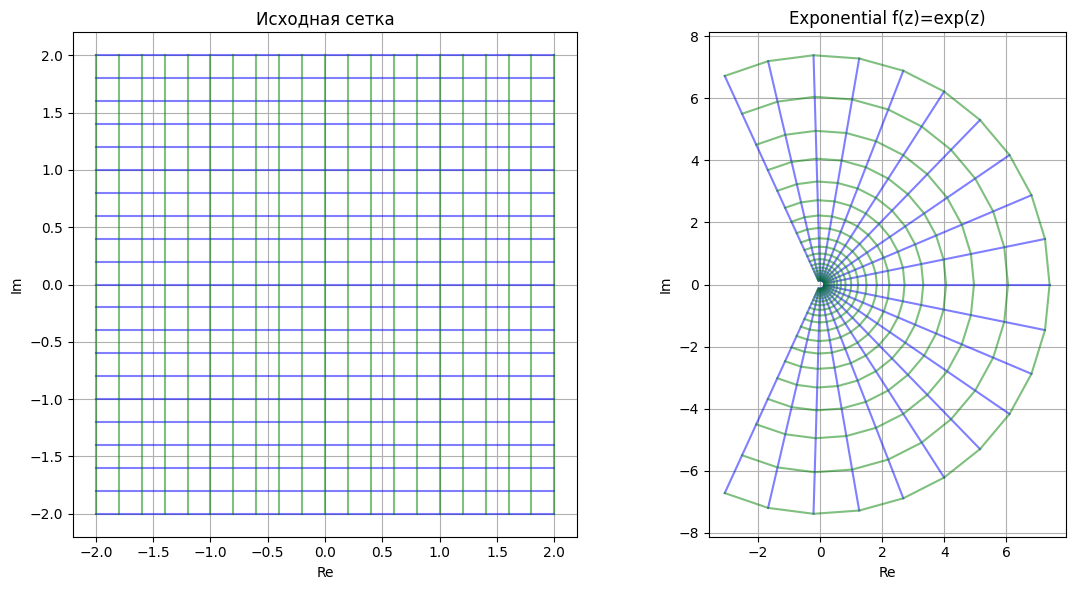

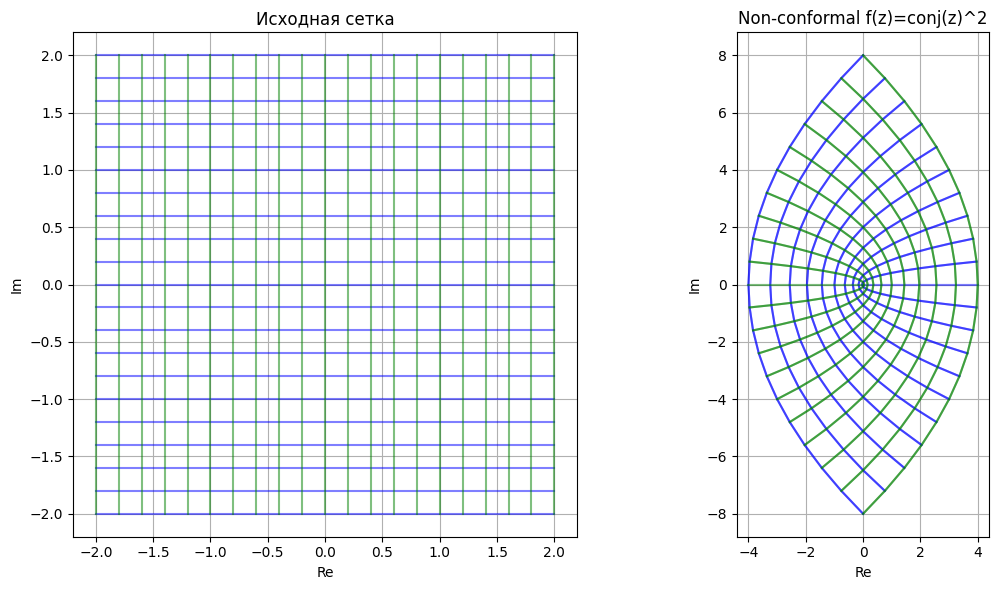

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Исходная сетка
x = np.linspace(-2, 2, 21)
y = np.linspace(-2, 2, 21)
X, Y = np.meshgrid(x, y)
Z = X + 1j*Y

# Отображения
def linear(z):
    return 2*z + 1

def inverse(z):
    with np.errstate(divide='ignore', invalid='ignore'):
        return 1/z

def exponential(z):
    return np.exp(z)

def mobius(z):
    with np.errstate(divide='ignore', invalid='ignore'):
        return (z-1j)/(z+1j)

def nonconformal(z):
    return np.conj(z)**2

mappings = {
    "Linear f(z)=2z+1": linear,
    "Exponential f(z)=exp(z)": exponential,
    "Non-conformal f(z)=conj(z)^2": nonconformal
}

# Цвета для горизонтальных и вертикальных линий
colors_h = 'blue'
colors_v = 'green'

for name, f in mappings.items():
    Z_mapped = np.array([f(row) for row in Z])
    Z_mapped = np.nan_to_num(Z_mapped, nan=0.0)  # заменяем NaN на 0
    
    fig, axes = plt.subplots(1, 2, figsize=(12,6))
    
    # Исходная сетка
    for row in Z:
        axes[0].plot(row.real, row.imag, color=colors_h, alpha=0.5)
    for col in Z.T:
        axes[0].plot(col.real, col.imag, color=colors_v, alpha=0.5)
    axes[0].set_title('Исходная сетка')
    axes[0].set_aspect('equal')
    axes[0].grid(True)
    
    # Преобразованная сетка
    for row in Z_mapped:
        axes[1].plot(row.real, row.imag, color=colors_h, alpha=0.5)
    for col in Z_mapped.T:
        axes[1].plot(col.real, col.imag, color=colors_v, alpha=0.5)
    axes[1].set_title(name)
    axes[1].set_aspect('equal')
    axes[1].grid(True)
    
    for ax in axes:
        ax.set_xlabel('Re')
        ax.set_ylabel('Im')
    
    plt.tight_layout()
    plt.show()
